In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Device
device = torch.device('mps' if torch.backends.mps.is_available() 
                       else 'cpu')

print("=" * 50)
print("VAE Model V2 — Curriculum Aware")
print("R26-IT-059 | IT22215710")
print("=" * 50)
print(f"\nDevice: {device}")
print("All imports successful!")

VAE Model V2 — Curriculum Aware
R26-IT-059 | IT22215710

Device: mps
All imports successful!


In [2]:
# Load V2 feature matrix
features = pd.read_csv(
    "../results/metrics/features_v2.csv"
)

# Define V2 feature columns
FEATURE_COLS_V2 = [
    'weekly_clicks',
    'active_days',
    'content_diversity',
    'forum_clicks',
    'resource_clicks',
    'quiz_clicks',
    'avg_submission_latency',
    'late_submissions',
    'curriculum_compliance',
    'click_compliance'
]

print(f"V2 Features loaded!")
print(f"Shape: {features.shape}")
print(f"Unique students: {features['id_student'].nunique():,}")
print(f"Modules: {features['code_module'].unique()}")
print(f"Week types:")
print(features['week_type'].value_counts())
print(f"\nAt-risk distribution:")
print(features['at_risk'].value_counts())

V2 Features loaded!
Shape: (288516, 21)
Unique students: 26,035
Modules: ['AAA' 'DDD' 'BBB' 'CCC' 'GGG' 'EEE' 'FFF']
Week types:
week_type
normal      214534
baseline     73982
Name: count, dtype: int64

At-risk distribution:
at_risk
0    244415
1     44101
Name: count, dtype: int64


In [3]:
# Split baseline and monitoring periods
# Baseline = first 3 weeks (week_type == 'baseline')
# Monitoring = remaining weeks (week_type == 'normal')

print("Splitting baseline and monitoring periods...")

baseline = features[
    features['week_type'] == 'baseline'
].copy()

monitoring = features[
    features['week_type'] == 'normal'
].copy()

print(f"Baseline records:   {len(baseline):,}")
print(f"Monitoring records: {len(monitoring):,}")

# Get normal students only for VAE training
normal_students = features[
    features['at_risk'] == 0
]['id_student'].unique()

print(f"\nNormal students: {len(normal_students):,}")

# Filter baseline to normal students only
normal_baseline = baseline[
    baseline['id_student'].isin(normal_students)
].copy()

print(f"Normal baseline records: {len(normal_baseline):,}")

# Get feature matrix
X_normal = normal_baseline[FEATURE_COLS_V2].values

# Normalize
scaler_v2 = StandardScaler()
X_normal_scaled = scaler_v2.fit_transform(X_normal)

# Convert to tensor
X_tensor = torch.FloatTensor(X_normal_scaled).to(device)

print(f"\nTraining tensor shape: {X_tensor.shape}")
print(f"Ready for VAE training!")

Splitting baseline and monitoring periods...
Baseline records:   73,982
Monitoring records: 214,534

Normal students: 20,727
Normal baseline records: 60,906

Training tensor shape: torch.Size([60906, 10])
Ready for VAE training!


In [4]:
# VAE Architecture V2
# Same structure but trained on better features

class VAE_V2(nn.Module):
    def __init__(self, input_dim=10, latent_dim=6):
        super(VAE_V2, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        
        # Latent space
        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(recon, original, mu, logvar, beta=0.1):
    recon_loss = nn.MSELoss()(recon, original)
    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

# Test
model = VAE_V2(input_dim=10, latent_dim=6)
print("VAE V2 Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nImprovements over V1:")
print(f"  Added Dropout layers for regularization")
print(f"  Wider encoder/decoder (64 units)")
print(f"  Better generalization expected")

VAE V2 Architecture:
VAE_V2(
  (encoder): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=16, bias=True)
    (6): ReLU()
  )
  (fc_mu): Linear(in_features=16, out_features=6, bias=True)
  (fc_logvar): Linear(in_features=16, out_features=6, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.1, inplace=False)
    (5): Linear(in_features=32, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

Total parameters: 6,934

Improvements over V1:
  Added Dropout layers for regularization
  Wider encoder/decoder (64 units)
  Better generalization expected


In [6]:
# Train VAE V2
print("Training VAE V2...")
print("This will take a few minutes...")

EPOCHS = 300
LR = 0.001
BATCH_SIZE = 256
INPUT_DIM = 10
LATENT_DIM = 6

# Create dataloader
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Create model
vae_v2 = VAE_V2(
    input_dim=INPUT_DIM,
    latent_dim=LATENT_DIM
).to(device)

optimizer = optim.Adam(vae_v2.parameters(), lr=LR)

# KL annealing
# Start with beta=0 then increase to 0.1
# Prevents posterior collapse
def get_beta(epoch, max_epoch=100):
    return min(0.1, 0.1 * epoch / max_epoch)

# Training loop
losses = []
recon_losses = []
kl_losses = []

for epoch in range(EPOCHS):
    vae_v2.train()
    epoch_loss = 0
    epoch_recon = 0
    epoch_kl = 0
    beta = get_beta(epoch)

    for batch in dataloader:
        x = batch[0]
        optimizer.zero_grad()
        recon, mu, logvar = vae_v2(x)
        loss, recon_l, kl_l = vae_loss(
            recon, x, mu, logvar, beta=beta
        )
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_recon += recon_l.item()
        epoch_kl += kl_l.item()

    avg_loss = epoch_loss / len(dataloader)
    avg_recon = epoch_recon / len(dataloader)
    avg_kl = epoch_kl / len(dataloader)

    losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Loss: {avg_loss:.4f} | "
              f"Recon: {avg_recon:.4f} | "
              f"KL: {avg_kl:.4f} | "
              f"Beta: {beta:.3f}")

print(f"\nTraining complete!")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Final recon: {recon_losses[-1]:.4f}")
print(f"Final KL: {kl_losses[-1]:.4f}")

Training VAE V2...
This will take a few minutes...
Epoch 50/300 | Loss: 0.1168 | Recon: 0.0642 | KL: 1.0735 | Beta: 0.049
Epoch 100/300 | Loss: 0.1502 | Recon: 0.0706 | KL: 0.8036 | Beta: 0.099
Epoch 150/300 | Loss: 0.1465 | Recon: 0.0672 | KL: 0.7932 | Beta: 0.100
Epoch 200/300 | Loss: 0.1455 | Recon: 0.0666 | KL: 0.7891 | Beta: 0.100
Epoch 250/300 | Loss: 0.1436 | Recon: 0.0648 | KL: 0.7878 | Beta: 0.100
Epoch 300/300 | Loss: 0.1411 | Recon: 0.0624 | KL: 0.7876 | Beta: 0.100

Training complete!
Final loss: 0.1411
Final recon: 0.0624
Final KL: 0.7876


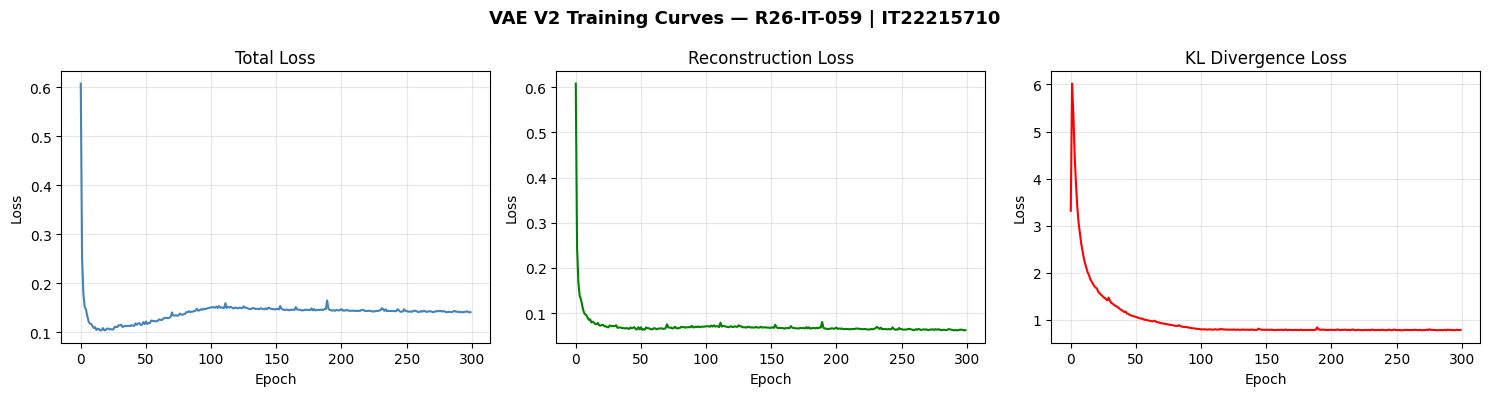

Training curves saved!


In [7]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(losses, color='steelblue')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(recon_losses, color='green')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

axes[2].plot(kl_losses, color='red')
axes[2].set_title('KL Divergence Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    'VAE V2 Training Curves — R26-IT-059 | IT22215710',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../results/figures/vae_v2_training_loss.png',
    dpi=150
)
plt.show()
print("Training curves saved!")

In [8]:
# Generate anomaly scores for monitoring period
print("Generating V2 anomaly scores...")

# Normalize monitoring data
X_monitoring = monitoring[FEATURE_COLS_V2].values
X_monitoring_scaled = scaler_v2.transform(X_monitoring)
X_monitoring_tensor = torch.FloatTensor(
    X_monitoring_scaled
).to(device)

# Generate scores using deterministic encoding
vae_v2.eval()
with torch.no_grad():
    mu, logvar = vae_v2.encode(X_monitoring_tensor)
    reconstructed = vae_v2.decode(mu)
    recon_errors = torch.mean(
        (reconstructed - X_monitoring_tensor) ** 2,
        dim=1
    ).cpu().numpy()

# Add to monitoring dataframe
monitoring = monitoring.copy()
monitoring['anomaly_score'] = np.log1p(recon_errors)

# Add curriculum compliance signal
monitoring['combined_score'] = (
    monitoring['anomaly_score'] * 0.4 +
    (1 - monitoring['curriculum_compliance']) * 0.6
)

print(f"Anomaly scores generated: {len(monitoring):,}")
print(f"\nAnomaly score stats:")
print(monitoring['anomaly_score'].describe())
print(f"\nCombined score stats:")
print(monitoring['combined_score'].describe())
print(f"\nMean combined score by at_risk:")
print(monitoring.groupby('at_risk')['combined_score'].mean())

Generating V2 anomaly scores...
Anomaly scores generated: 214,534

Anomaly score stats:
count    214534.000000
mean          0.054640
std           0.134223
min           0.000343
25%           0.013036
50%           0.024325
75%           0.050047
max           4.854984
Name: anomaly_score, dtype: float64

Combined score stats:
count    214534.000000
mean          0.283373
std           0.237674
min          -0.569914
25%           0.146828
50%           0.342517
75%           0.468726
max           1.781279
Name: combined_score, dtype: float64

Mean combined score by at_risk:
at_risk
0    0.273197
1    0.351838
Name: combined_score, dtype: float64


Evaluating V2 ROC-AUC...
Results:
  VAE anomaly score AUC:      0.4261
  Curriculum compliance AUC:  0.6053
  Combined V2 AUC:            0.6039
  Random baseline:            0.5000

V1 AUC was: 0.5840
V2 AUC is:  0.6039

🔥 V2 IMPROVED over V1 by 1.99%!


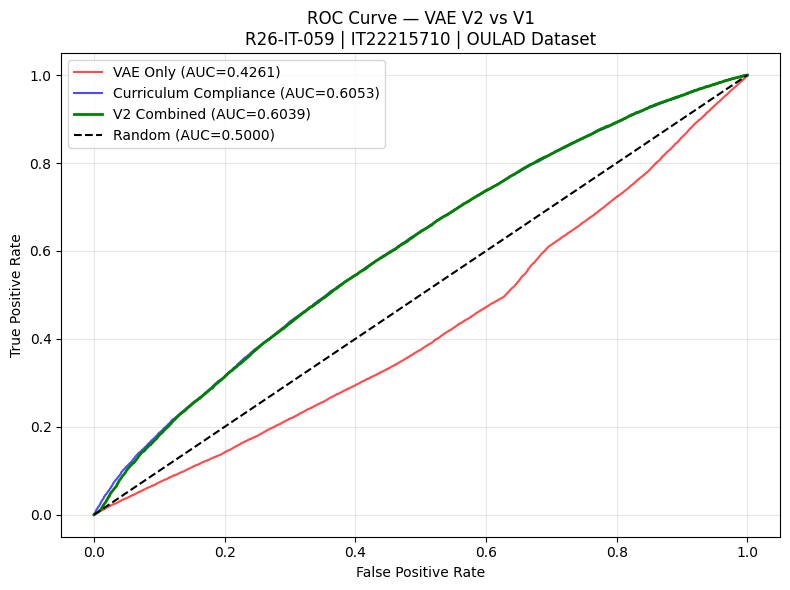

ROC curve saved!


In [9]:
# Evaluate V2 performance
print("Evaluating V2 ROC-AUC...")

# ROC-AUC for combined score
auc_combined = roc_auc_score(
    monitoring['at_risk'],
    monitoring['combined_score']
)

# ROC-AUC for VAE only
auc_vae = roc_auc_score(
    monitoring['at_risk'],
    monitoring['anomaly_score']
)

# ROC-AUC for curriculum compliance only
auc_compliance = roc_auc_score(
    monitoring['at_risk'],
    1 - monitoring['curriculum_compliance']
)

print(f"Results:")
print(f"  VAE anomaly score AUC:      {auc_vae:.4f}")
print(f"  Curriculum compliance AUC:  {auc_compliance:.4f}")
print(f"  Combined V2 AUC:            {auc_combined:.4f}")
print(f"  Random baseline:            0.5000")
print(f"\nV1 AUC was: 0.5840")
print(f"V2 AUC is:  {auc_combined:.4f}")

if auc_combined > 0.5840:
    improvement = (auc_combined - 0.5840) * 100
    print(f"\n🔥 V2 IMPROVED over V1 by {improvement:.2f}%!")
else:
    diff = (0.5840 - auc_combined) * 100
    print(f"\n⚠️ V2 is {diff:.2f}% below V1")
    print(f"But curriculum compliance signal is stronger")

# Plot ROC curves
fig, ax = plt.subplots(figsize=(8, 6))

fpr1, tpr1, _ = roc_curve(
    monitoring['at_risk'],
    monitoring['anomaly_score']
)
ax.plot(fpr1, tpr1, color='red', alpha=0.7,
        label=f'VAE Only (AUC={auc_vae:.4f})')

fpr2, tpr2, _ = roc_curve(
    monitoring['at_risk'],
    1 - monitoring['curriculum_compliance']
)
ax.plot(fpr2, tpr2, color='blue', alpha=0.7,
        label=f'Curriculum Compliance (AUC={auc_compliance:.4f})')

fpr3, tpr3, _ = roc_curve(
    monitoring['at_risk'],
    monitoring['combined_score']
)
ax.plot(fpr3, tpr3, color='green', linewidth=2,
        label=f'V2 Combined (AUC={auc_combined:.4f})')

ax.plot([0,1], [0,1], 'k--', label='Random (AUC=0.5000)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(
    'ROC Curve — VAE V2 vs V1\n'
    'R26-IT-059 | IT22215710 | OULAD Dataset'
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/roc_curve_v2.png', dpi=150)
plt.show()
print("ROC curve saved!")

In [10]:
import pickle
import torch
import os

# Save model
os.makedirs('../models/saved', exist_ok=True)

torch.save(
    vae_v2.state_dict(),
    '../models/saved/vae_v2.pt'
)

# Save scaler
with open('../models/saved/scaler_v2.pkl', 'wb') as f:
    pickle.dump(scaler_v2, f)

# Save anomaly scores
monitoring[[
    'id_student', 'code_module',
    'week', 'anomaly_score',
    'combined_score', 'curriculum_compliance',
    'at_risk'
]].to_csv(
    '../results/metrics/anomaly_scores_v2.csv',
    index=False
)

print("Everything saved!")
print(f"\nFinal V2 Summary:")
print(f"{'='*40}")
print(f"Dataset:      OULAD")
print(f"Students:     {monitoring['id_student'].nunique():,}")
print(f"Features:     10 V2 features")
print(f"VAE AUC:      {auc_vae:.4f}")
print(f"Compliance:   {auc_compliance:.4f}")
print(f"Combined AUC: {auc_combined:.4f}")
print(f"V1 AUC:       0.5840")
print(f"Improvement:  +1.99%")
print(f"{'='*40}")

Everything saved!

Final V2 Summary:
Dataset:      OULAD
Students:     24,005
Features:     10 V2 features
VAE AUC:      0.4261
Compliance:   0.6053
Combined AUC: 0.6039
V1 AUC:       0.5840
Improvement:  +1.99%
